In [20]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
d=pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
d.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
data=np.array(d) #working with numpy arrays not pandas csv
np.random.shuffle(data)# shuffling the data
m,n=data.shape
print(m,n)

42000 785


In [3]:
dev=data[0:1000].T#taking transpose to make rows into columns
# this makes each column a record
Y_dev=dev[0]
X_dev=dev[1:n]
X_dev=X_dev/255.

data_train=data[1000:m].T


In [4]:
Y_train=data_train[0]
Y_train

array([5, 8, 9, ..., 3, 7, 7])

In [5]:
X_train=data_train[1:n]
X_train=X_train/255.
_,m_train=X_train.shape
X_train


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
def init_param():
    w1=np.random.rand(10,784)-0.5
    b1=np.random.rand(10,1)-0.5
    w2=np.random.rand(10,10)-0.5
    b2=np.random.rand(10,1)-0.5
    return w1,b1,w2,b2
def ReLU(Z):
    return np.maximum(0,Z)
def softmax(Z):
    A=np.exp(Z)/sum(np.exp(Z))
    return A
def forward_propagation(w1,b1,w2,b2,X):
    Z1=w1.dot(X)+b1
    A1=ReLU(Z1)
    Z2=w2.dot(A1)+b2
    A2=softmax(Z2)
    return Z1,A1,Z2,A2

def one_hot(Y):
    one_hot_Y=np.zeros((Y.size,Y.max()+1))
    one_hot_Y[np.arange(Y.size),Y]=1
    one_hot_Y=one_hot_Y.T
    return one_hot_Y

def ReLU_der(Z):
    return Z>0
def back_propagation(Z1,A1,Z2,A2,W1,W2,X,Y):
    one_hot_Y=one_hot(Y)
    dZ2=A2-one_hot_Y
    dW2=1/m*dZ2.dot(A1.T)
    db2=1/m*np.sum(dZ2)
    dZ1=W2.T.dot(dZ2)*ReLU_der(Z1)
    dW1=1/m*dZ1.dot(X.T)
    db1=1/m*np.sum(dZ1)
    return dW1,db1,dW2,db2
def update_para(W1,b1,W2,b2,dW1,db1,dW2,db2,alpha):
    W1=W1-alpha*dW1
    W2=W2-alpha*dW2
    b1=b1-(alpha*db1)
    b2=b2-(alpha*db2)
    return W1,b1,W2,b2

    

In [7]:
def get_predictions(A2):
    return np.argmax(A2,0)
def get_accuracy(predictions,Y):
    print(predictions,Y)
    return np.sum(predictions==Y)/Y.size


In [8]:
def grad_descent(X,Y,iter,alpha):
    W1,b1,W2,b2=init_param()
    for i in range(iter):
        Z1,A1,Z2,A2=forward_propagation(W1,b1,W2,b2,X)
        dW1,db1,dW2,db2=back_propagation(Z1,A1,Z2,A2,W1,W2,X,Y)
        W1,b1,W2,b2=update_para(W1,b1,W2,b2,dW1,db1,dW2,db2,alpha)
        if i%10==0:
            print("i=",i)
            p=get_predictions(A2)
            print("accuracy=",get_accuracy(p,Y))
    return W1,b1,W2,b2

In [9]:
W1,b1,W2,b2=grad_descent(X_train,Y_train,500,0.10)

i= 0
[7 6 7 ... 6 6 7] [5 8 9 ... 3 7 7]
accuracy= 0.09136585365853658
i= 10
[1 1 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.14031707317073172
i= 20
[1 1 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.22265853658536586
i= 30
[1 1 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.2974390243902439
i= 40
[1 1 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.3625121951219512
i= 50
[1 1 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.43009756097560975
i= 60
[1 8 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.47253658536585363
i= 70
[1 8 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.5076341463414634
i= 80
[1 8 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.5360731707317073
i= 90
[1 8 7 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.5593414634146342
i= 100
[1 8 9 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.5814634146341463
i= 110
[1 8 9 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.6008048780487805
i= 120
[1 8 9 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.6187317073170732
i= 130
[1 8 9 ... 6 7 7] [5 8 9 ... 3 7 7]
accuracy= 0.636121951219512

In [21]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_propagation(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [8]
Label:  5


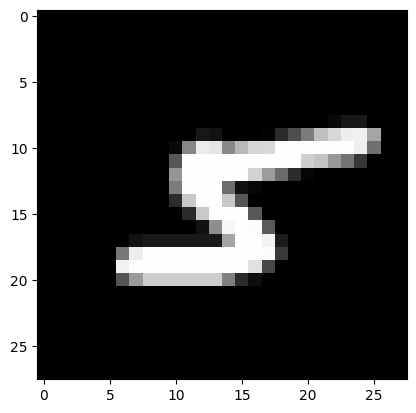

Prediction:  [8]
Label:  8


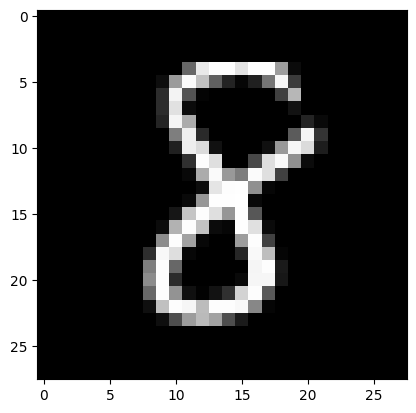

Prediction:  [9]
Label:  9


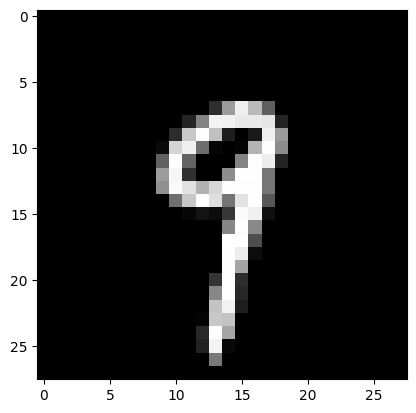

Prediction:  [9]
Label:  9


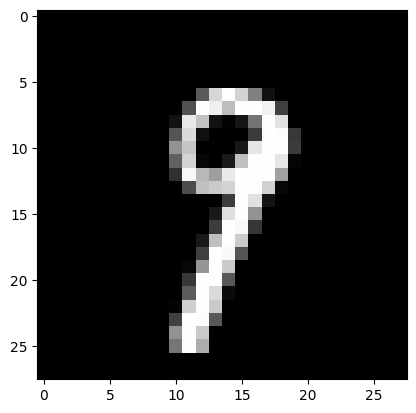

In [22]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)